# STUDENT PERFORMANCE PREDICTION


### DATASET USED : 

-> Student dataset (UCI)

-> Features include demographics, attendance, study time, and prior grades

### EDA Highlights:

-> Correlation analysis performed

-> Outliers handled using IQR (for absences)

-> Key influencing factors identified


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the dataset
df = pd.read_csv("student-mat.csv", sep=';')

In [6]:
# IQR OUTLIER DETECTION + CAPPING
# Numeric features used in model

num_cols = ['age', 'studytime', 'absences', 'Medu', 'Fedu']

In [7]:
# Function to detect outliers
# -----------------------------------
def detect_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        print(f"{col}: {len(outliers)} outliers")

In [8]:
# Function to cap outliers
# -----------------------------------
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Cap values
        df[col] = df[col].clip(lower, upper)
        
    return df

In [9]:
# Step 1: Detect outliers
# -----------------------------------
print("Before Handling Outliers:")
detect_outliers(df, num_cols)

Before Handling Outliers:
age: 1 outliers
studytime: 27 outliers
absences: 15 outliers
Medu: 0 outliers
Fedu: 2 outliers


In [10]:
# Step 2: Apply capping
# -----------------------------------
df = cap_outliers(df, num_cols)

# -----------------------------------
# Step 3: Check again
# -----------------------------------
print("\nAfter Handling Outliers:")
detect_outliers(df, num_cols)


After Handling Outliers:
age: 0 outliers
studytime: 0 outliers
absences: 0 outliers
Medu: 0 outliers
Fedu: 0 outliers


In [11]:
# 3. Create Target Variable (Pass/Fail)
# -----------------------------------
df['result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [12]:
# 4. Basic EDA
# -----------------------------------
print(df.head())
print(df.info())
print(df['result'].value_counts())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4   4.0  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1   1.0  at_home     other  ...   
2     GP   F   15       U     LE3       T     1   1.0  at_home     other  ...   
3     GP   F   15       U     GT3       T     4   2.0   health  services  ...   
4     GP   F   16       U     GT3       T     3   3.0    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3 result  
0        3     4     1     1       3        6   5   6   6      0  
1        3     3     1     1       3        4   5   5   6      0  
2        3     2     2     3       3       10   7   8  10      1  
3        2     2     1     1       5        2  15  14  15      1  
4        3     2     1     2       5        4   6  10  10      1  

[5 rows x 34 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (to

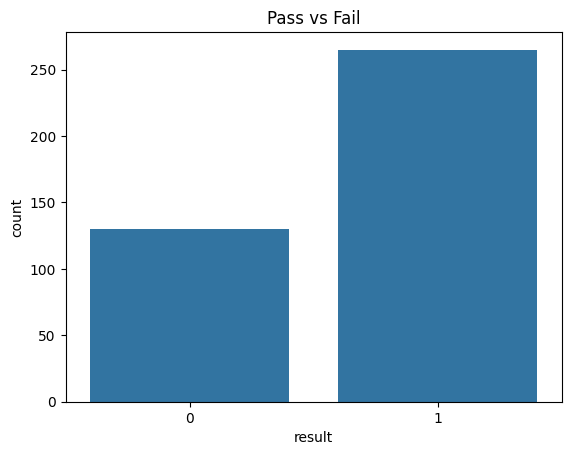

In [13]:
# 5. Visualization 
# -----------------------------------
sns.countplot(x='result', data=df)
plt.title("Pass vs Fail")
plt.show()

### Interpretation
- There are more students passing than failing.
- Pass (1) dominates Fail (0) in the dataset, indicating a slightly imbalanced target variable.
- This shows that while predicting failure is important, the dataset has fewer examples of failing students, which may require careful handling during model training.

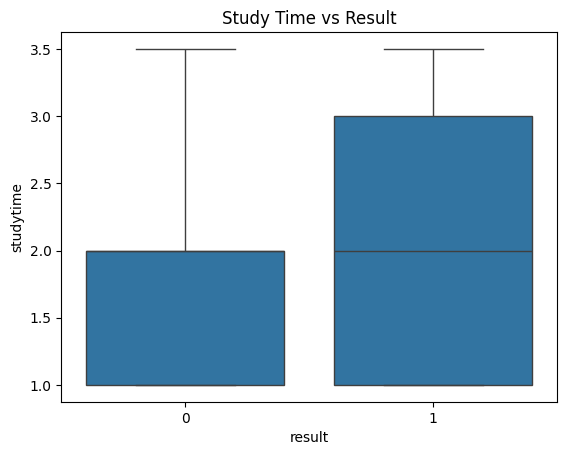

In [14]:
sns.boxplot(x='result', y='studytime', data=df)
plt.title("Study Time vs Result")
plt.show()

### Interpretation
- Students who study more tend to have higher chances of passing.
- Median study time is slightly higher for passing students compared to failing students.
- However, some students with lower study time still pass, suggesting other factors (like parental education, previous grades) also influence performance.

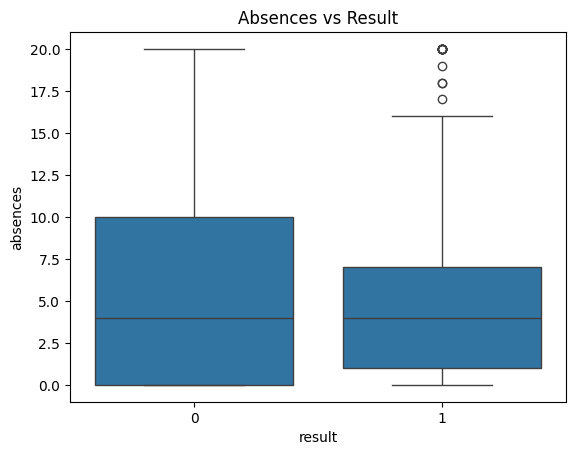

In [15]:
sns.boxplot(x='result', y='absences', data=df)
plt.title("Absences vs Result")
plt.show()

### interpretation
Students with higher absences are more likely to fail.

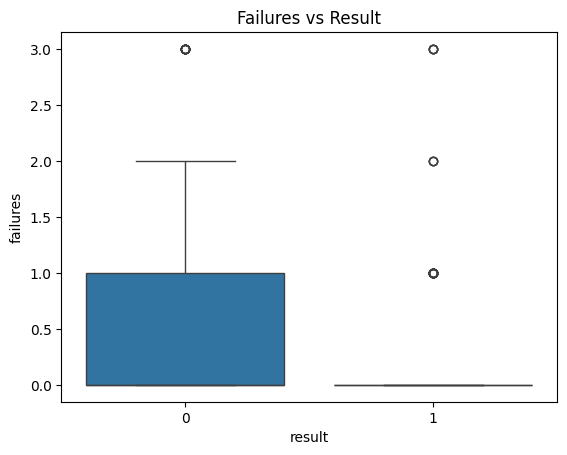

In [16]:
sns.boxplot(x='result', y='failures', data=df)
plt.title("Failures vs Result")
plt.show()

### Interpretation
- Most students have 0 past failures.
- The boxplot appears flat because failures is an ordinal variable with limited values and low variation.
- Students with past failures are more likely to fail in the final grade, but since most values are 0, IQR-based outlier detection is not applied to this feature.
- This feature is kept as it still provides predictive value for the model.

In [17]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
result        0
dtype: int64


In [18]:
print(df['failures'].value_counts())

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64


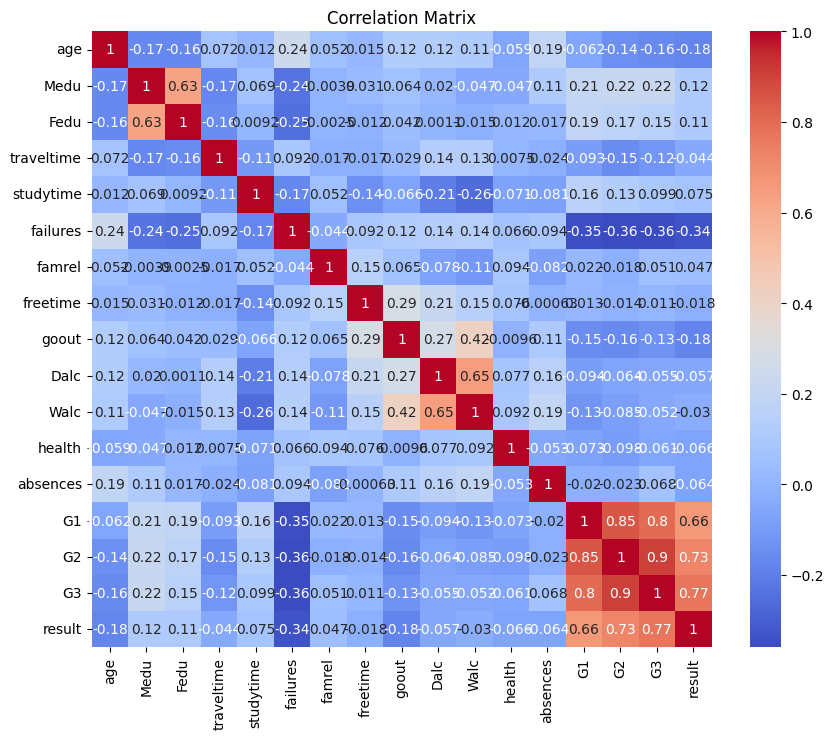

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

interpretation: 
G1 and G2 are highly correlated with G3, so they were removed to avoid data leakage

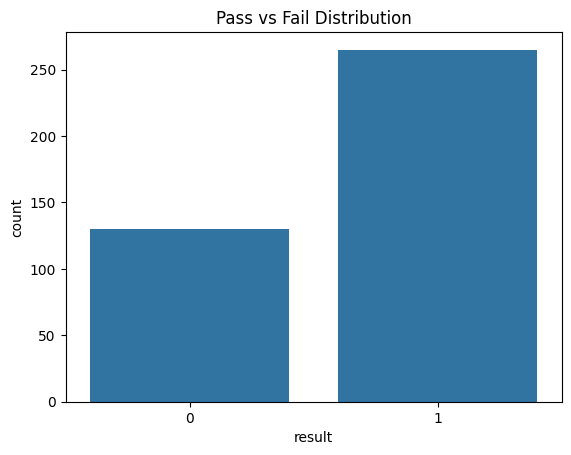

In [20]:
sns.countplot(x='result', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()


interpretation:
Dataset is slightly imbalanced with more passing students.

<Axes: xlabel='sex', ylabel='count'>

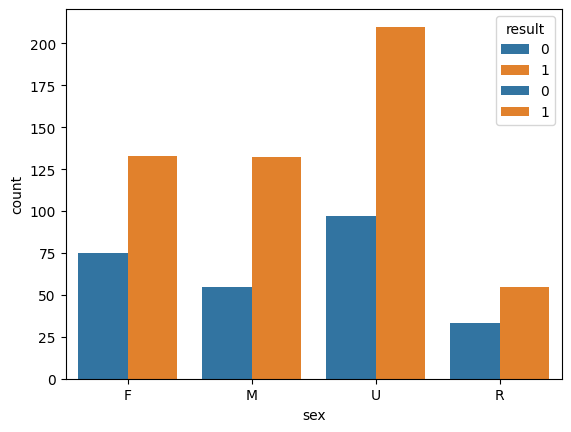

In [21]:
sns.countplot(x='sex', hue='result', data=df)
sns.countplot(x='address', hue='result', data=df)


interpretation:
Urban students show slightly better performance trends.

In [22]:
# Encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Feature-target split
X = df_encoded.drop("result", axis=1)
y = df_encoded["result"]

print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (395, 43)


## Data Preprocessing

- Categorical variables were converted into numerical form using one-hot encoding.
- `drop_first=True` was used to avoid multicollinearity.
- Features (X) and target (y) were separated for model training.

### Feature Selection
- G1 and G2 were removed as they are highly correlated with final grade (G3).
- Removing them prevents data leakage and improves model fairness.

##  Conclusion

From the exploratory data analysis, several important insights were observed. Absences have a strong negative impact on student performance, while parental education shows a positive influence. The dataset is slightly imbalanced with more students passing than failing.

Correlation analysis revealed that G1 and G2 are highly correlated with the final grade (G3), so they were removed to avoid data leakage. Outliers were identified in the 'absences' feature and handled using IQR capping, while ordinal features like 'failures' were not treated for outliers due to low variation.

Overall, student performance is influenced by a combination of academic behavior and socio-economic factors. These insights were used to guide preprocessing and model building.
